In [ ]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score, accuracy_score
from sklearn.model_selection import train_test_split
from string import punctuation
from nltk.corpus import wordnet, stopwords
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist
from nltk.stem import WordNetLemmatizer
from nltk.tag import pos_tag
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Load Pre-trained Model and Data

In [ ]:
# Define preprocessing functions
def tag_to_wordnet(tag: str):
    if tag.startswith('J'):
        return wordnet.ADJ
    if tag.startswith('V'):
        return wordnet.VERB
    if tag.startswith('R'):
        return wordnet.ADV
    if tag.startswith('N'):
        return wordnet.NOUN
    return wordnet.NOUN

def preprocess(sentences: str):
    tokens = word_tokenize(sentences)
    cleaned_tokens = [token.lower() for token in tokens if token.lower() not in stopwords.words('english') and token.lower() not in punctuation]
    tagged_tokens = pos_tag(cleaned_tokens)
    stemmed_tokens = [WordNetLemmatizer().lemmatize(token, tag_to_wordnet(tag)) for token, tag in tagged_tokens]
    return stemmed_tokens

def feature_extraction(tokens: list[str], fd: FreqDist):
    dict_feature = {}
    for token in fd.keys():
        dict_feature[token] = (token in tokens)
    return dict_feature

df = pd.read_csv('Symptom2Disease.csv')
print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())

sentences = "  ".join(df['text'])
cleaned_tokens = preprocess(sentences)
fd = FreqDist(cleaned_tokens)

X = df['text']
y = df['label']

print(f"\nClass distribution:")
print(y.value_counts())

# Load the pre-trained model
with open("model.pkl", "rb") as f:
    model = pickle.load(f)
print("\nModel loaded successfully!")

Dataset loaded successfully!
Dataset shape: (1200, 3)

First few rows:
   Unnamed: 0      label                                               text
0           0  Psoriasis  I have been experiencing a skin rash on my arm...
1           1  Psoriasis  My skin has been peeling, especially on my kne...
2           2  Psoriasis  I have been experiencing joint pain in my fing...
3           3  Psoriasis  There is a silver like dusting on my skin, esp...
4           4  Psoriasis  My nails have small dents or pits in them, and...

Class distribution:
label
Psoriasis                          50
Varicose Veins                     50
Typhoid                            50
Chicken pox                        50
Impetigo                           50
Dengue                             50
Fungal infection                   50
Common Cold                        50
Pneumonia                          50
Dimorphic Hemorrhoids              50
Arthritis                          50
Acne                        

## 3. Generate Predictions on Test Data

In [ ]:
all_features = [(feature_extraction(preprocess(statement), fd), label) for statement, label in zip(X, y)]

train_data, test_data = train_test_split(all_features, test_size=0.2, random_state=42)

y_true = [label for _, label in test_data]
y_pred = [model.classify(features) for features, _ in test_data]

print(f"Total test samples: {len(y_true)}")
print(f"Predictions generated successfully!")

accuracy = accuracy_score(y_true, y_pred)
print(f"\nOverall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

Total test samples: 240
Predictions generated successfully!

Overall Accuracy: 0.9667 (96.67%)


## 4. Confusion Matrix Visualization

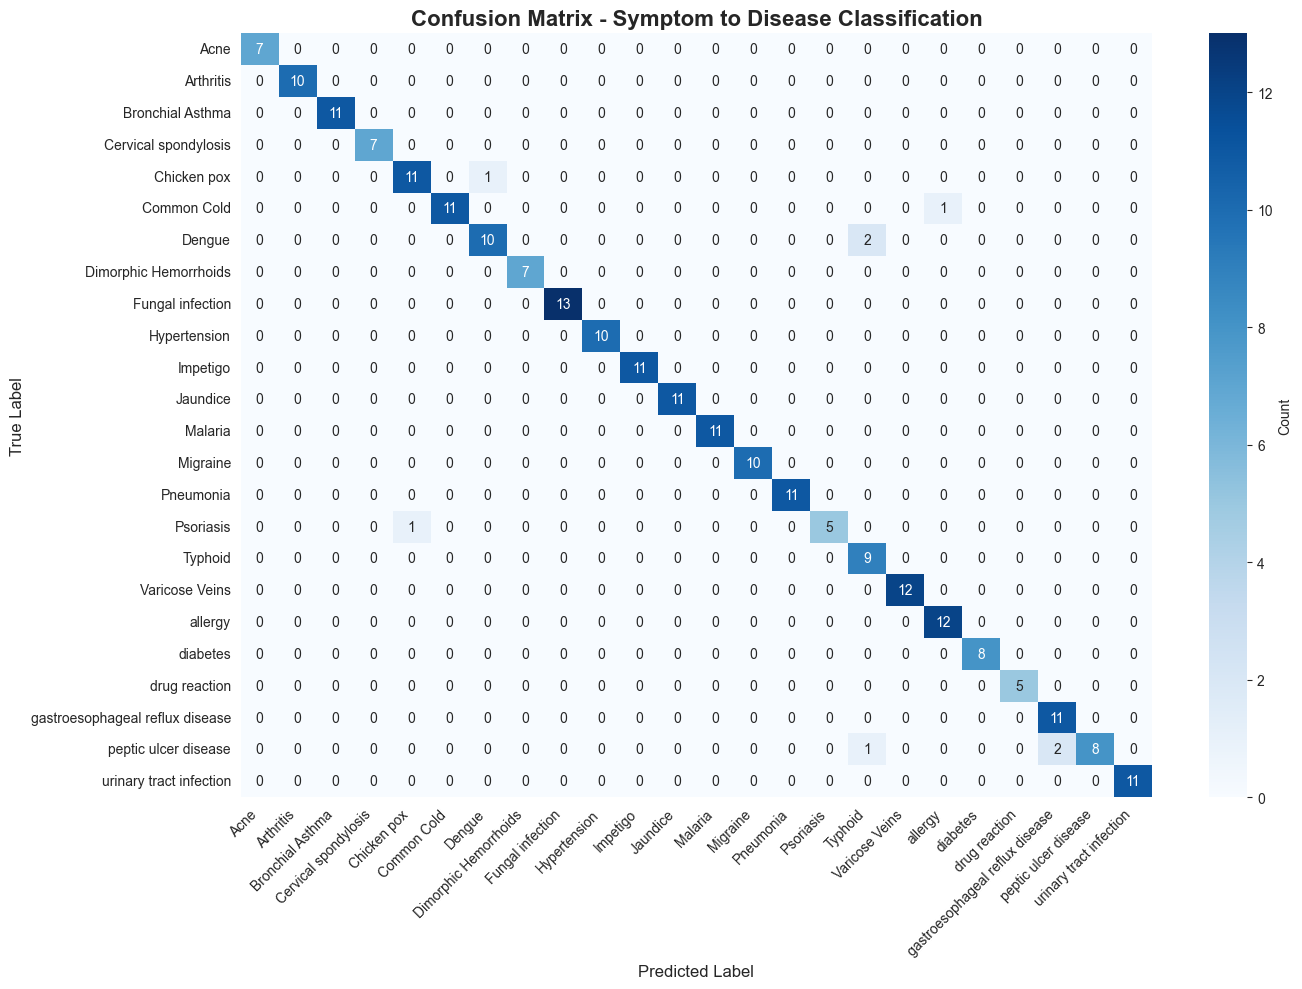

Classes: ['Acne', 'Arthritis', 'Bronchial Asthma', 'Cervical spondylosis', 'Chicken pox', 'Common Cold', 'Dengue', 'Dimorphic Hemorrhoids', 'Fungal infection', 'Hypertension', 'Impetigo', 'Jaundice', 'Malaria', 'Migraine', 'Pneumonia', 'Psoriasis', 'Typhoid', 'Varicose Veins', 'allergy', 'diabetes', 'drug reaction', 'gastroesophageal reflux disease', 'peptic ulcer disease', 'urinary tract infection']
Number of classes: 24


In [5]:
# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=sorted(set(y_true)))
class_labels = sorted(set(y_true))

# Plot confusion matrix
plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels, 
            yticklabels=class_labels,
            cbar_kws={'label': 'Count'},
            annot_kws={"size": 10})
plt.title('Confusion Matrix - Symptom to Disease Classification', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"Classes: {class_labels}")
print(f"Number of classes: {len(class_labels)}")

## 5. Classification Metrics Report

In [6]:
# Generate classification report
report = classification_report(y_true, y_pred, output_dict=True)
print("\n" + "="*80)
print("CLASSIFICATION REPORT")
print("="*80)
print(classification_report(y_true, y_pred))

# Create a DataFrame for better visualization
report_df = pd.DataFrame(report).transpose()
print("\nMetrics DataFrame:")
print(report_df)


CLASSIFICATION REPORT
                                 precision    recall  f1-score   support

                           Acne       1.00      1.00      1.00         7
                      Arthritis       1.00      1.00      1.00        10
               Bronchial Asthma       1.00      1.00      1.00        11
           Cervical spondylosis       1.00      1.00      1.00         7
                    Chicken pox       0.92      0.92      0.92        12
                    Common Cold       1.00      0.92      0.96        12
                         Dengue       0.91      0.83      0.87        12
          Dimorphic Hemorrhoids       1.00      1.00      1.00         7
               Fungal infection       1.00      1.00      1.00        13
                   Hypertension       1.00      1.00      1.00        10
                       Impetigo       1.00      1.00      1.00        11
                       Jaundice       1.00      1.00      1.00        11
                        Mal

## 6. Per-Class Performance Metrics Visualization

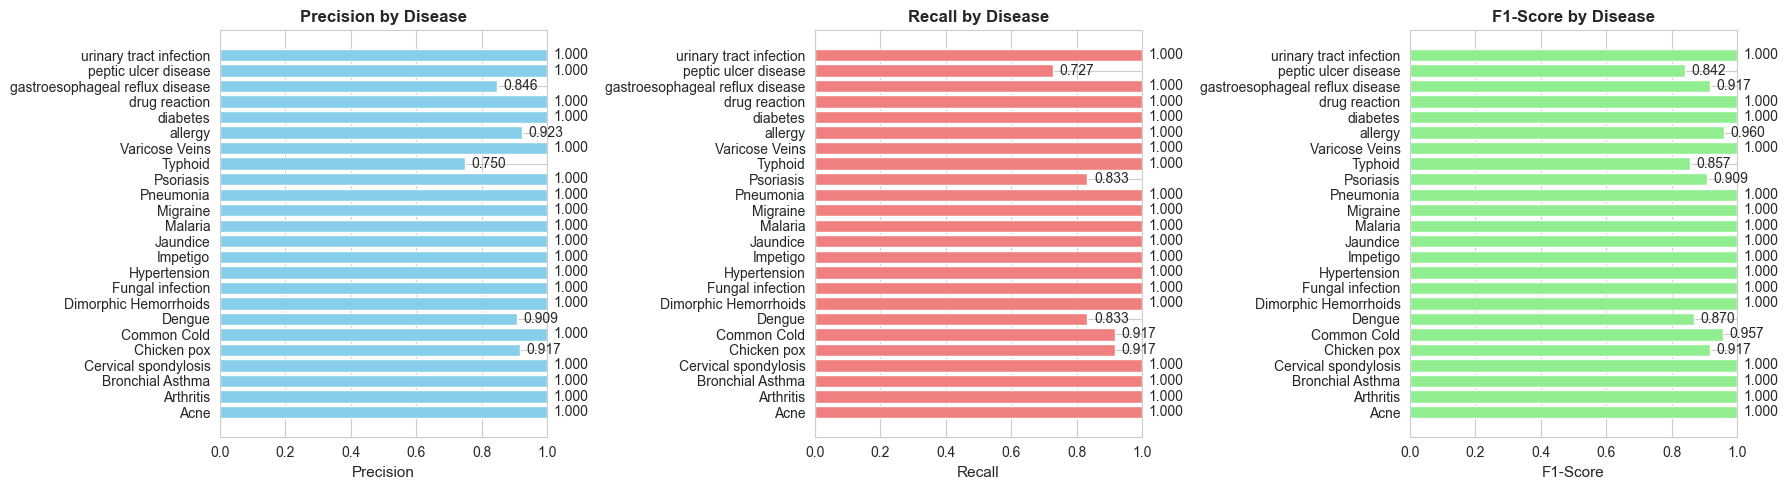

In [7]:
# Extract per-class metrics
report_dict = classification_report(y_true, y_pred, output_dict=True)
classes = [c for c in report_dict.keys() if c not in ['accuracy', 'macro avg', 'weighted avg']]

precision_scores = [report_dict[c]['precision'] for c in classes]
recall_scores = [report_dict[c]['recall'] for c in classes]
f1_scores = [report_dict[c]['f1-score'] for c in classes]

# Plot per-class metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Precision plot
axes[0].barh(classes, precision_scores, color='skyblue')
axes[0].set_xlabel('Precision', fontsize=11)
axes[0].set_title('Precision by Disease', fontsize=12, fontweight='bold')
axes[0].set_xlim([0, 1])
for i, v in enumerate(precision_scores):
    axes[0].text(v + 0.02, i, f'{v:.3f}', va='center')

# Recall plot
axes[1].barh(classes, recall_scores, color='lightcoral')
axes[1].set_xlabel('Recall', fontsize=11)
axes[1].set_title('Recall by Disease', fontsize=12, fontweight='bold')
axes[1].set_xlim([0, 1])
for i, v in enumerate(recall_scores):
    axes[1].text(v + 0.02, i, f'{v:.3f}', va='center')

# F1-Score plot
axes[2].barh(classes, f1_scores, color='lightgreen')
axes[2].set_xlabel('F1-Score', fontsize=11)
axes[2].set_title('F1-Score by Disease', fontsize=12, fontweight='bold')
axes[2].set_xlim([0, 1])
for i, v in enumerate(f1_scores):
    axes[2].text(v + 0.02, i, f'{v:.3f}', va='center')

plt.tight_layout()
plt.show()

## 7. Class Distribution Comparison

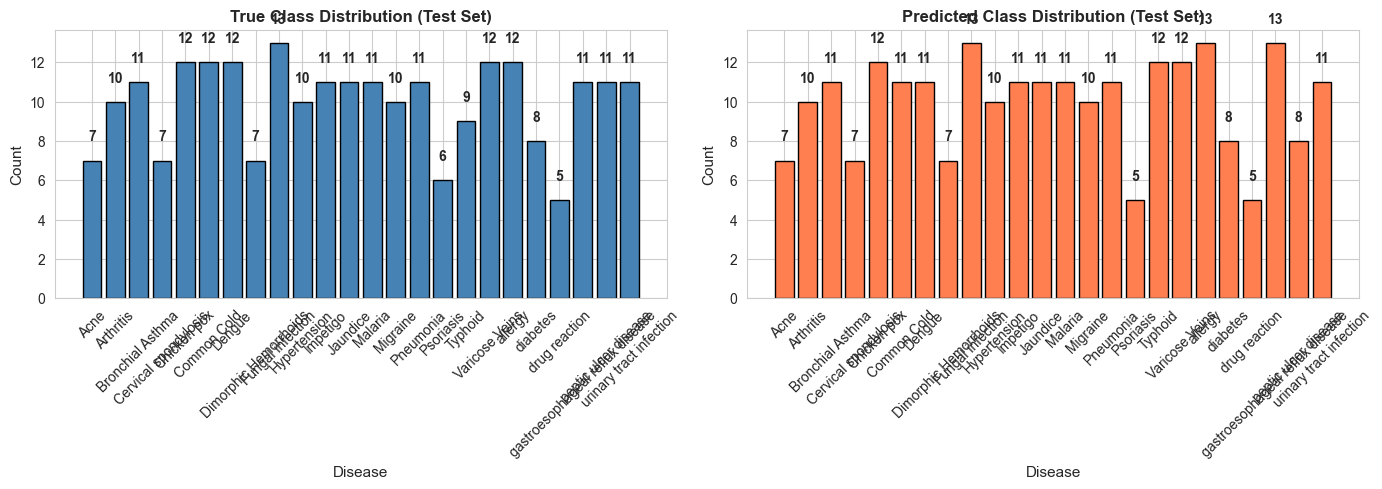

In [8]:
# Compare true vs predicted distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# True distribution
true_counts = pd.Series(y_true).value_counts().sort_index()
axes[0].bar(true_counts.index, true_counts.values, color='steelblue', edgecolor='black')
axes[0].set_title('True Class Distribution (Test Set)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_xlabel('Disease', fontsize=11)
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(true_counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Predicted distribution
pred_counts = pd.Series(y_pred).value_counts().sort_index()
axes[1].bar(pred_counts.index, pred_counts.values, color='coral', edgecolor='black')
axes[1].set_title('Predicted Class Distribution (Test Set)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_xlabel('Disease', fontsize=11)
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(pred_counts.values):
    axes[1].text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Model Performance Summary

In [9]:
# Calculate overall metrics
overall_accuracy = accuracy_score(y_true, y_pred)
macro_precision = precision_score(y_true, y_pred, average='macro')
macro_recall = recall_score(y_true, y_pred, average='macro')
macro_f1 = f1_score(y_true, y_pred, average='macro')
weighted_precision = precision_score(y_true, y_pred, average='weighted')
weighted_recall = recall_score(y_true, y_pred, average='weighted')
weighted_f1 = f1_score(y_true, y_pred, average='weighted')

# Create summary DataFrame
summary_data = {
    'Metric': ['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1-Score',
               'Weighted Precision', 'Weighted Recall', 'Weighted F1-Score'],
    'Score': [overall_accuracy, macro_precision, macro_recall, macro_f1,
              weighted_precision, weighted_recall, weighted_f1]
}
summary_df = pd.DataFrame(summary_data)

print("\n" + "="*60)
print("MODEL PERFORMANCE SUMMARY")
print("="*60)
print(summary_df.to_string(index=False))
print("="*60)


MODEL PERFORMANCE SUMMARY
            Metric    Score
          Accuracy 0.966667
   Macro Precision 0.972708
      Macro Recall 0.967803
    Macro F1-Score 0.967823
Weighted Precision 0.971015
   Weighted Recall 0.966667
 Weighted F1-Score 0.966452


## 9. Performance Metrics Visualization

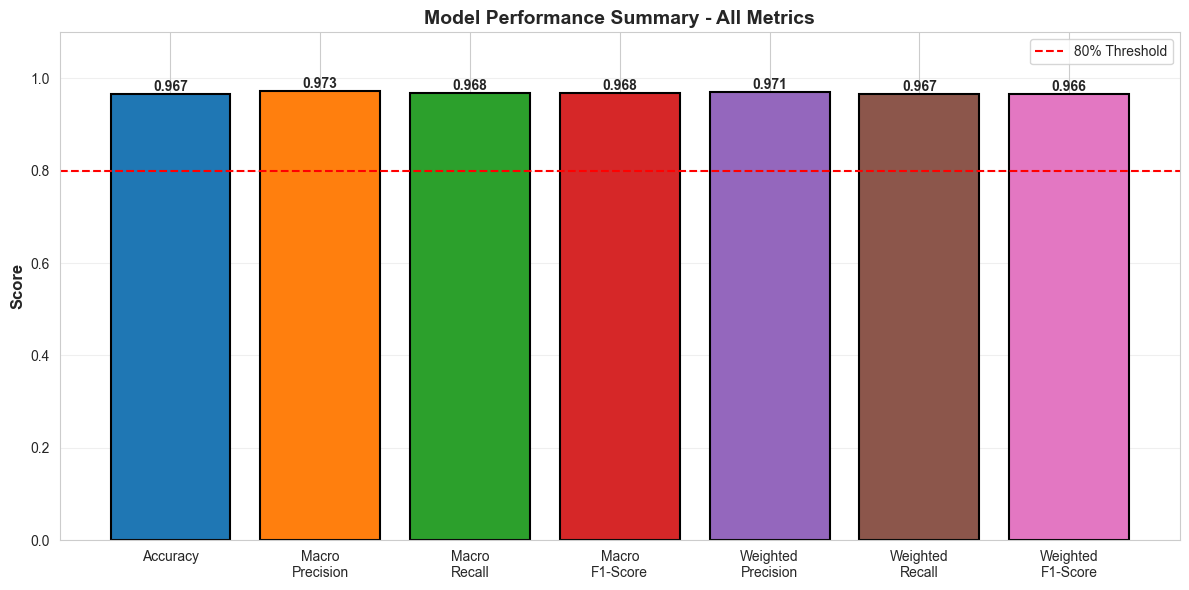

In [10]:
# Create summary visualization
fig, ax = plt.subplots(figsize=(12, 6))

metrics = ['Accuracy', 'Macro\nPrecision', 'Macro\nRecall', 'Macro\nF1-Score',
           'Weighted\nPrecision', 'Weighted\nRecall', 'Weighted\nF1-Score']
scores = [overall_accuracy, macro_precision, macro_recall, macro_f1,
          weighted_precision, weighted_recall, weighted_f1]

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']
bars = ax.bar(metrics, scores, color=colors, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar, score in zip(bars, scores):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{score:.3f}',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Summary - All Metrics', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1.1])
ax.axhline(y=0.8, color='r', linestyle='--', linewidth=1.5, label='80% Threshold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Prediction Accuracy by Disease Class

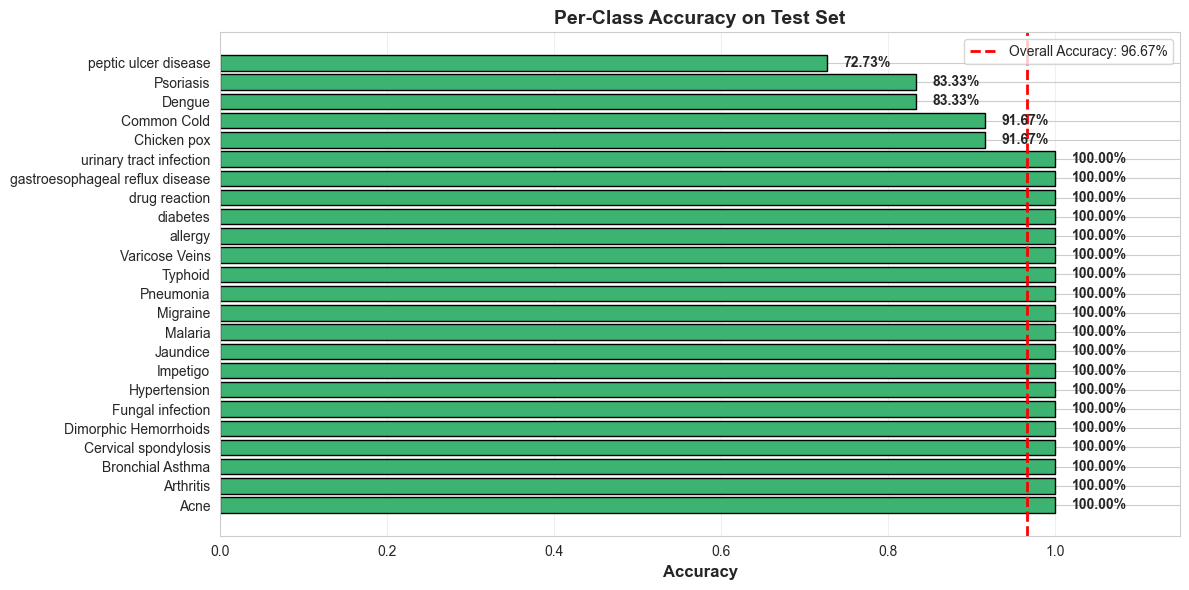


Per-Class Accuracy:
Acne                : 100.00%
Arthritis           : 100.00%
Bronchial Asthma    : 100.00%
Cervical spondylosis: 100.00%
Dimorphic Hemorrhoids: 100.00%
Fungal infection    : 100.00%
Hypertension        : 100.00%
Impetigo            : 100.00%
Jaundice            : 100.00%
Malaria             : 100.00%
Migraine            : 100.00%
Pneumonia           : 100.00%
Typhoid             : 100.00%
Varicose Veins      : 100.00%
allergy             : 100.00%
diabetes            : 100.00%
drug reaction       : 100.00%
gastroesophageal reflux disease: 100.00%
urinary tract infection: 100.00%
Chicken pox         : 91.67%
Common Cold         : 91.67%
Dengue              : 83.33%
Psoriasis           : 83.33%
peptic ulcer disease: 72.73%


In [11]:
# Calculate per-class accuracy
class_accuracies = {}
for disease in class_labels:
    mask = np.array(y_true) == disease
    if mask.sum() > 0:
        class_acc = (np.array(y_pred)[mask] == disease).sum() / mask.sum()
        class_accuracies[disease] = class_acc

# Sort by accuracy
sorted_classes = sorted(class_accuracies.items(), key=lambda x: x[1], reverse=True)
classes_sorted = [c[0] for c in sorted_classes]
accuracies_sorted = [c[1] for c in sorted_classes]

# Plot per-class accuracy
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(classes_sorted, accuracies_sorted, color='mediumseagreen', edgecolor='black')

# Add value labels
for i, (bar, acc) in enumerate(zip(bars, accuracies_sorted)):
    ax.text(acc + 0.02, i, f'{acc:.2%}', va='center', fontweight='bold')

ax.set_xlabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Per-Class Accuracy on Test Set', fontsize=14, fontweight='bold')
ax.set_xlim([0, 1.15])
ax.axvline(x=overall_accuracy, color='red', linestyle='--', linewidth=2, label=f'Overall Accuracy: {overall_accuracy:.2%}')
ax.legend(fontsize=10)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nPer-Class Accuracy:")
for disease, acc in sorted_classes:
    print(f"{disease:20s}: {acc:.2%}")

## 11. Error Analysis

In [12]:
# Identify misclassified samples
misclassified_indices = np.where(np.array(y_true) != np.array(y_pred))[0]
correct_indices = np.where(np.array(y_true) == np.array(y_pred))[0]

print(f"\nError Analysis:")
print(f"Total Test Samples: {len(y_true)}")
print(f"Correct Predictions: {len(correct_indices)} ({len(correct_indices)/len(y_true)*100:.2f}%)")
print(f"Misclassified Samples: {len(misclassified_indices)} ({len(misclassified_indices)/len(y_true)*100:.2f}%)")

# Create error matrix (which classes are confused)
if len(misclassified_indices) > 0:
    misclass_true = np.array(y_true)[misclassified_indices]
    misclass_pred = np.array(y_pred)[misclassified_indices]
    
    print("\nTop Misclassification Pairs (True -> Predicted):")
    error_pairs = pd.DataFrame({
        'True': misclass_true,
        'Predicted': misclass_pred
    })
    error_pairs_count = error_pairs.groupby(['True', 'Predicted']).size().sort_values(ascending=False)
    print(error_pairs_count.head(10))


Error Analysis:
Total Test Samples: 240
Correct Predictions: 232 (96.67%)
Misclassified Samples: 8 (3.33%)

Top Misclassification Pairs (True -> Predicted):
True                  Predicted                      
Dengue                Typhoid                            2
peptic ulcer disease  gastroesophageal reflux disease    2
Chicken pox           Dengue                             1
Common Cold           allergy                            1
Psoriasis             Chicken pox                        1
peptic ulcer disease  Typhoid                            1
dtype: int64


## 12. Feature Frequency Distribution

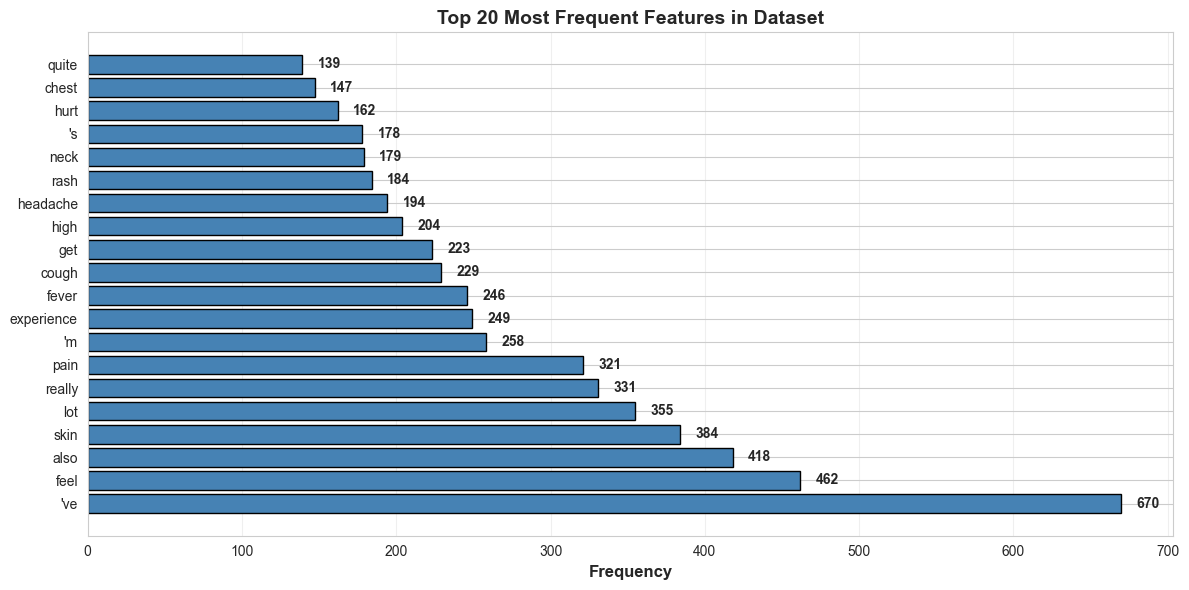


Top 20 Features:
've                 :   670
feel                :   462
also                :   418
skin                :   384
lot                 :   355
really              :   331
pain                :   321
'm                  :   258
experience          :   249
fever               :   246
cough               :   229
get                 :   223
high                :   204
headache            :   194
rash                :   184
neck                :   179
's                  :   178
hurt                :   162
chest               :   147
quite               :   139


In [13]:
# Get top features from frequency distribution
top_n = 20
top_features = fd.most_common(top_n)
feature_names = [f[0] for f in top_features]
feature_counts = [f[1] for f in top_features]

# Plot top features
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(feature_names, feature_counts, color='steelblue', edgecolor='black')

# Add value labels
for bar, count in zip(bars, feature_counts):
    ax.text(count + 10, bar.get_y() + bar.get_height()/2, f'{count}',
            va='center', fontweight='bold')

ax.set_xlabel('Frequency', fontsize=12, fontweight='bold')
ax.set_title(f'Top {top_n} Most Frequent Features in Dataset', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTop {top_n} Features:")
for feature, count in top_features:
    print(f"{feature:20s}: {count:5d}")